In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

In [3]:
# 1. LOAD DATASET
# =========================================
df = pd.read_csv('Placement_Data_Updated.csv')
# =========================================
# 2. PREPROCESSING
# =========================================
df['Placement'] = df['status'].map({'Placed': 1, 'Not Placed': 0})

df_new = pd.DataFrame({
    'CGPA': df['degree_p'] / 10,
    'Academic_Performance': df['hsc_p'] / 10,
    'Prev_Sem_Result': df['ssc_p'] / 10,
    'Internship_Experience': df['workex'].map({'Yes': 1, 'No': 0}),
    'Aptitude_Score': df['etest_p'],
    'Communication_Skills': df['mba_p'] / 10,

    'Projects_Completed': df['Projects_Completed'],
    'Extra_Curricular_Score': df['Extra_Curricular_Score'],

    'Placement': df['Placement']
})

In [4]:
# 3. BALANCE DATASET
# =========================================
df_placed = df_new[df_new['Placement'] == 1]
df_not = df_new[df_new['Placement'] == 0]

df_not_upsampled = resample(df_not, replace=True,
                           n_samples=len(df_placed),
                           random_state=42)

df_new = pd.concat([df_placed, df_not_upsampled])

In [5]:
# 4. FEATURES
# =========================================
features = [
    'CGPA', 'Projects_Completed', 'Internship_Experience',
    'Communication_Skills', 'Aptitude_Score',
    'Academic_Performance', 'Prev_Sem_Result',
    'Extra_Curricular_Score'
]

In [6]:
# INPUT labels (with scale)
feature_input_names = {
    'CGPA': 'CGPA (0–10)',
    'Projects_Completed': 'Projects Completed (1–5)',
    'Internship_Experience': 'Internship (0=No, 1=Yes)',
    'Communication_Skills': 'Communication Skills (0–10)',
    'Aptitude_Score': 'Aptitude Score (0–100)',
    'Academic_Performance': '12th Percentage (0–10)',
    'Prev_Sem_Result': 'Previous Semester (0–10)',
    'Extra_Curricular_Score': 'Extra Activities (0–10)'
}
# OUTPUT labels (clean)
feature_output_names = {
    'CGPA': 'CGPA',
    'Projects_Completed': 'Projects',
    'Internship_Experience': 'Internship',
    'Communication_Skills': 'Communication Skills',
    'Aptitude_Score': 'Aptitude',
    'Academic_Performance': 'Academic Performance',
    'Prev_Sem_Result': 'Previous Semester',
    'Extra_Curricular_Score': 'Extra Curricular'
}
X = df_new[features]
y = df_new['Placement']


In [7]:
# 5. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train Test split done")

Train Test split done


In [8]:
# 6. MODELS
lr = LogisticRegression(max_iter=2000, C=0.5, random_state=42)
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
rf = RandomForestClassifier(n_estimators=150, max_depth=6,
                            min_samples_split=10, random_state=42)

lr.fit(X_train_scaled, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

ensemble = VotingClassifier(
    estimators=[('lr', lr), ('dt', dt), ('rf', rf)],
    voting='soft',
    weights=[2, 1, 3]
)
ensemble.fit(X_train_scaled, y_train)


VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=0.5, max_iter=2000,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     min_samples_split=10,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(max_depth=6,
                                                     min_samples_split=10,
                                                     n_estimators=150,
                                                     random_state=42))],
                 voting='soft', weights=[2, 1, 3])


 MODEL PERFORMANCE
Logistic Regression : 85.00%
Decision Tree       : 88.33%
Random Forest       : 90.00%
Ensemble Model ⭐   : 93.33%

 Classification Report (Ensemble)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        31
           1       1.00      0.86      0.93        29

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



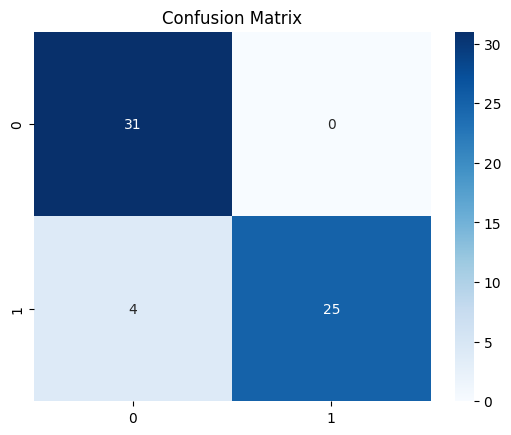

In [9]:
# 7. EVALUATION
print("\n MODEL PERFORMANCE")

lr_pred = lr.predict(X_test_scaled)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
ens_pred = ensemble.predict(X_test_scaled)

print(f"Logistic Regression : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"Decision Tree       : {accuracy_score(y_test, dt_pred)*100:.2f}%")
print(f"Random Forest       : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"Ensemble Model ⭐   : {accuracy_score(y_test, ens_pred)*100:.2f}%")

print("\n Classification Report (Ensemble)\n")
print(classification_report(y_test, ens_pred))

cm = confusion_matrix(y_test, ens_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [10]:
# 8. FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
# 9. USER INPUT (WITH SCALE)
print("\n ENTER YOUR DETAILS:\n")

user_data = []

for f in features:
    val = float(input(f"Enter {feature_input_names[f]}: "))
    user_data.append(val)

user_scaled = scaler.transform([user_data])


 ENTER YOUR DETAILS:

Enter CGPA (0–10): 7.8
Enter Projects Completed (1–5): 2
Enter Internship (0=No, 1=Yes): 0
Enter Communication Skills (0–10): 8.5
Enter Aptitude Score (0–100): 75
Enter 12th Percentage (0–10): 9.2
Enter Previous Semester (0–10): 7.8
Enter Extra Activities (0–10): 8.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
# 10. PREDICTION
prob = ensemble.predict_proba(user_scaled)[0][1]
prob = max(0.1, min(prob, 0.9))

prediction = "PLACED ✅" if prob > 0.5 else "NOT PLACED ❌"

In [12]:
# 11. SMART SKILL SELECTION
placed_data = X[y == 1]

important_features = importance.head(5)['Feature'].values

weak_features = []
for f in features:
    if user_data[features.index(f)] < placed_data[f].mean():
        weak_features.append(f)

final_features = []

for f in important_features:
    if f in weak_features:
        final_features.append(f)

if len(final_features) < 3:
    for f in weak_features:
        if f not in final_features:
            final_features.append(f)
        if len(final_features) == 3:
            break

# 12. IMPROVEMENT PLAN
print("\n GENERATING IMPROVEMENT PLAN...\n")

improvement_plan = []

for f in final_features:
    idx = features.index(f)
    target_val = placed_data[f].mean()

    improved = user_data.copy()
    improved[idx] = target_val

    new_prob = ensemble.predict_proba(
        scaler.transform([improved])
    )[0][1]

    improvement_plan.append({
        'feature': f,
        'current': user_data[idx],
        'target': target_val,
        'new_prob': new_prob * 100,
        'gain': (new_prob - prob) * 100
    })




 GENERATING IMPROVEMENT PLAN...



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
# 13. FINAL OUTPUT
print("\n" + "="*50)
print(" FINAL RESULT")
print("="*50)

print(f"Prediction: {prediction}")
print(f"Placement Probability: {prob*100:.2f}%")

print("\n Skills to Focus:")
for f in final_features:
    print(f"- {feature_output_names[f]}")

print("\n IMPROVEMENT PLAN")
print("="*50)

for i, p in enumerate(improvement_plan, 1):
    print(f"\nStep {i}: Improve {feature_output_names[p['feature']]}")
    print(f"   Current: {p['current']:.2f}")
    print(f"   Target : {p['target']:.2f}")
    print(f"   New Probability: {p['new_prob']:.2f}%")
    print(f"   Gain: +{p['gain']:.2f}%")

print("="*50)


 FINAL RESULT
Prediction: PLACED ✅
Placement Probability: 81.31%

 Skills to Focus:
- Projects
- Internship

 IMPROVEMENT PLAN

Step 1: Improve Projects
   Current: 2.00
   Target : 3.36
   New Probability: 82.51%
   Gain: +1.20%

Step 2: Improve Internship
   Current: 0.00
   Target : 0.43
   New Probability: 82.45%
   Gain: +1.14%
